In [1]:
# Do countries with higher Human Development Index (HDI) tend to have a higher or lower share of a dominant religion?

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("final_dataset.csv")

religion_cols = [
    "christianity",
    "judaism",
    "islam",
    "buddhism",
    "hindu",
    "shinto",
    "confus_tao"
]

# Convert religion counts to population shares
for col in religion_cols:
    df[col] = df[col] / df["population"]

# Identify dominant religion share
df["dominant_share"] = df[religion_cols].max(axis=1)

# Clean data
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["hdi","dominant_share"])

In [3]:
df[["hdi","dominant_share"]].describe()

,hdi,dominant_share
count,743.000000,743.000000
mean,0.648331,0.794410
std,0.173343,0.225774
min,0.210000,0.080945
25%,0.510000,0.675945
50%,0.670000,0.842060
75%,0.780000,0.926005
max,0.940000,2.956982


In [12]:
df[religion_cols].describe()

,christianity,judaism,islam,buddhism,hindu,shinto,confus_tao
count,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000
mean,0.554829,0.006186,0.237969,0.047965,0.025365,0.005357,0.000382
std,0.378754,0.063586,0.357496,0.207187,0.105195,0.065134,0.004747
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.092322,0.000000,0.002192,0.000000,0.000000,0.000000,0.000000
50%,0.700504,0.000037,0.033438,0.000098,0.000000,0.000000,0.000000
75%,0.883315,0.000531,0.367914,0.002003,0.001460,0.000000,0.000000
max,2.197585,0.820469,1.331528,2.956982,0.788221,0.843289,0.109209


In [13]:
religion_cols = [
    "christianity",
    "judaism",
    "islam",
    "buddhism",
    "hindu",
    "shinto",
    "confus_tao"
]

# 1) original sum
df["religion_sum_before"] = df[religion_cols].sum(axis=1)

# 2) avoiding diving by zero
df = df[df["religion_sum_before"] > 0].copy()

# 3) normalizing
df[religion_cols] = df[religion_cols].div(df["religion_sum_before"], axis=0)

# 4) recalculating sum after normalization
df["religion_sum_after"] = df[religion_cols].sum(axis=1)

# 5) recalculating dominant_share
df["dominant_share"] = df[religion_cols].max(axis=1)

print(df["religion_sum_before"].describe())
print(df["religion_sum_after"].describe())
print(df["dominant_share"].describe())

count    743.000000
mean       0.878054
std        0.221287
min        0.157589
25%        0.805280
50%        0.901148
75%        0.958285
max        3.440912
Name: religion_sum_before, dtype: float64
count    7.430000e+02
mean     1.000000e+00
std      8.559090e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: religion_sum_after, dtype: float64
count    743.000000
mean       0.901624
std        0.136812
min        0.330682
25%        0.865083
50%        0.964394
75%        0.993919
max        1.000000
Name: dominant_share, dtype: float64


In [14]:
df[religion_cols].describe()

,christianity,judaism,islam,buddhism,hindu,shinto,confus_tao
count,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000,743.000000
mean,0.650654,0.006620,0.259546,0.052121,0.027014,0.003509,0.000536
std,0.411289,0.065955,0.369419,0.188041,0.112333,0.042604,0.005879
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.110804,0.000000,0.003017,0.000000,0.000000,0.000000,0.000000
50%,0.935716,0.000038,0.043495,0.000111,0.000000,0.000000,0.000000
75%,0.991693,0.000577,0.452152,0.002244,0.002019,0.000000,0.000000
max,1.000000,0.832292,0.999837,0.976842,0.845526,0.543378,0.133309


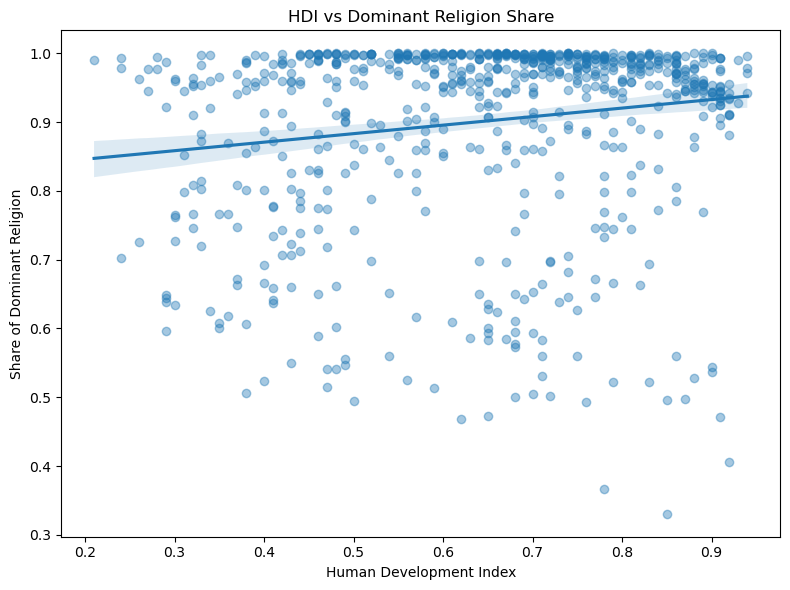

In [20]:
# Import libraries for visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Create figure with defined size
plt.figure(figsize=(8,6))

# Create regression plot (scatter + regression line)
sns.regplot(
    data=df,                 # DataFrame containing the data
    x="hdi",                 # variable on the x-axis
    y="dominant_share",      # variable on the y-axis
    scatter_kws={"alpha":0.4}  # transparency for points
)

# Add title and axis labels
plt.title("HDI vs Dominant Religion Share")
plt.xlabel("Human Development Index")
plt.ylabel("Share of Dominant Religion")

# Adjust layout so labels are not cut off
plt.tight_layout()

# Save the figure to a file (high resolution)
plt.savefig(
    "hdi_vs_dominant_religion.png",  # file name
    dpi=300,                         # resolution (good for reports)
    bbox_inches="tight"              # avoids cropping labels
)

# Display the plot
plt.show()

In [21]:
from scipy.stats import spearmanr

# Calculate the Spearman correlation between two variables:
# "hdi" (Human Development Index) and "dominant_share" (share of the dominant religion)
# Spearman correlation measures the strength and direction of a monotonic relationship
# between two variables based on ranked values rather than raw values
corr, p = spearmanr(df["hdi"], df["dominant_share"])

# Print the Spearman correlation coefficient
# This value ranges between -1 and 1
#  1   = perfect positive monotonic relationship
#  0   = no monotonic relationship
# -1   = perfect negative monotonic relationship
print("Spearman correlation:", corr)

# Print the p-value associated with the correlation test
# The p-value tests the null hypothesis that there is no correlation
# If p < 0.05, the correlation is considered statistically significant
print("p-value:", p)

Spearman correlation: 0.09962453860658727
p-value: 0.006572548738442431


In [22]:
import statsmodels.api as sm

# Create a new DataFrame containing only the variables needed for the regression
# "hdi" is the independent variable and "dominant_share" is the dependent variable
# dropna() removes rows with missing values to avoid errors in the regression
df_reg = df[["hdi","dominant_share"]].dropna()

# Define the independent variable (predictor)
# Here we use HDI as the explanatory variable
# sm.add_constant() adds an intercept term (β0) to the regression model
# This allows the regression line to have a non-zero intercept
X = sm.add_constant(df_reg["hdi"])

# Define the dependent variable (the outcome we want to explain)
# In this case, the share of the dominant religion
y = df_reg["dominant_share"]

# Fit an Ordinary Least Squares (OLS) regression model
# OLS estimates the coefficients that minimize the squared differences
# between the observed values and the predicted values
model = sm.OLS(y, X).fit()

# Print a detailed summary of the regression results
# The summary includes:
# - coefficients (effect size of each variable)
# - R-squared (how much variance the model explains)
# - p-values (statistical significance)
# - standard errors and confidence intervals
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         dominant_share   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     18.71
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           1.73e-05
Time:                        13:38:45   Log-Likelihood:                 433.43
No. Observations:                 743   AIC:                            -862.9
Df Residuals:                     741   BIC:                            -853.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8213      0.019     42.741      0.0

In [ ]:
# HDI and conflit

In [23]:
# Convert the "hdi" column to numeric values
# If any value cannot be converted (for example text or invalid characters),
# errors="coerce" will replace it with NaN (missing value)
df["hdi"] = pd.to_numeric(df["hdi"], errors="coerce")

# Convert the "conflict_present" column to numeric values as well
# This ensures the variable can be used in statistical models and calculations
# Any non-numeric values will again be replaced with NaN
df["conflict_present"] = pd.to_numeric(df["conflict_present"], errors="coerce")

# Replace infinite values (positive or negative infinity) with NaN
# Infinite values can appear during data processing and would break statistical models
df = df.replace([np.inf, -np.inf], np.nan)

# Remove rows where either "hdi" or "conflict_present" is missing
# This step ensures the dataset used in the analysis contains only valid observations
# required for regression or correlation calculations
df = df.dropna(subset=["hdi", "conflict_present"])

In [24]:
df.groupby("conflict_present")["hdi"].mean()

conflict_present
0.0    0.672528
1.0    0.514825
Name: hdi, dtype: float64

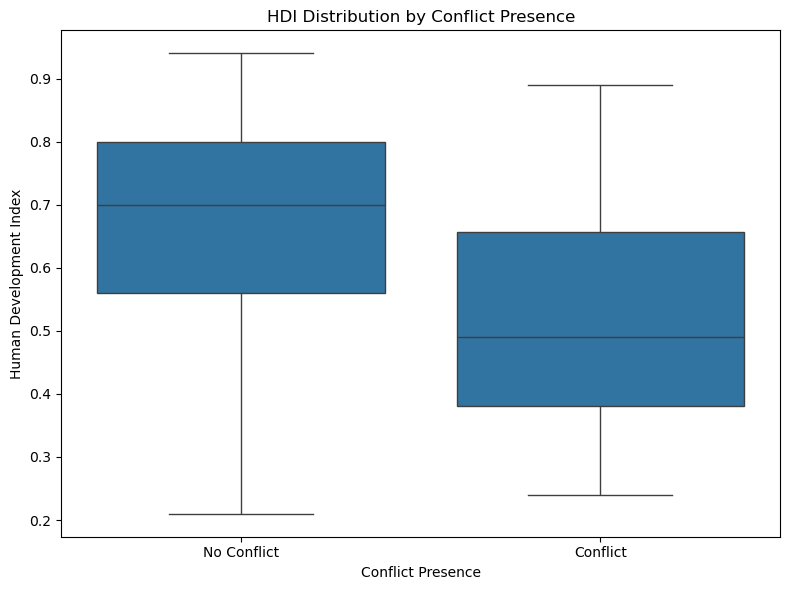

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# manter apenas linhas válidas
plot_df = df[["conflict_present", "hdi"]].dropna().copy()

# labels mais legíveis
plot_df["conflict_present_label"] = plot_df["conflict_present"].map({
    0: "No Conflict",
    1: "Conflict"
})

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=plot_df,
    x="conflict_present_label",
    y="hdi"
)

plt.title("HDI Distribution by Conflict Presence")
plt.xlabel("Conflict Presence")
plt.ylabel("Human Development Index")
plt.tight_layout()

# guardar gráfico
plt.savefig("hdi_boxplot_conflict.png", dpi=300, bbox_inches="tight")

plt.show()

In [26]:
# Prepare the data for the logistic regression
# Keep only the columns needed for the analysis and remove rows with missing values
plot_df = df[["hdi", "conflict_present"]].dropna().copy()

# Define the independent variable (predictor)
# Here, HDI is used to explain variation in conflict presence
X = plot_df["hdi"]

# Add a constant to the model
# This creates the intercept term, allowing the model to estimate a baseline probability
# when HDI is equal to zero
X = sm.add_constant(X)

# Define the dependent variable (outcome)
# conflict_present is the binary variable the model is trying to predict
# Typically, 0 means no conflict and 1 means conflict
y = plot_df["conflict_present"]

# Fit the logistic regression model
# Logit is appropriate here because the dependent variable is binary
# The model estimates how changes in HDI affect the probability of conflict
logit_model = sm.Logit(y, X).fit()

# Print the full summary of the logistic regression results
# This includes coefficients, p-values, standard errors,
# pseudo R-squared, and goodness-of-fit statistics
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.375026
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:       conflict_present   No. Observations:                  743
Model:                          Logit   Df Residuals:                      741
Method:                           MLE   Df Model:                            1
Date:                Thu, 12 Mar 2026   Pseudo R-squ.:                  0.1250
Time:                        13:42:25   Log-Likelihood:                -278.64
converged:                       True   LL-Null:                       -318.46
Covariance Type:            nonrobust   LLR p-value:                 4.504e-19
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5149      0.373      4.065      0.000       0.785       2.245
hdi           -5.4235      0.

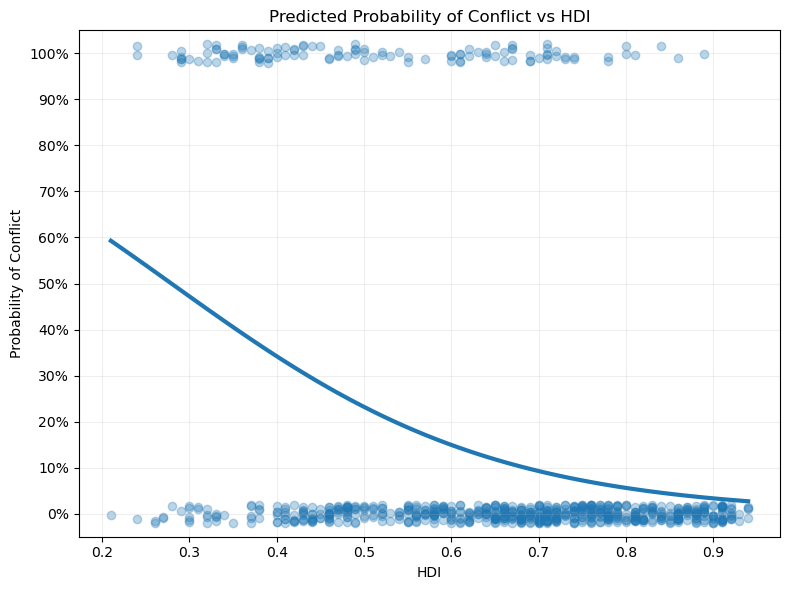

In [25]:
# Import required libraries
# numpy for numerical operations, pandas for data handling,
# matplotlib for plotting, statsmodels for statistical models,
# and PercentFormatter to format the Y-axis as percentages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from matplotlib.ticker import PercentFormatter

# Keep only valid rows for the analysis
# Rows where either HDI or conflict_present is missing are removed
plot_df = df[["hdi", "conflict_present"]].dropna().copy()

# Create a range of HDI values spanning the observed data
# These values will be used to draw the predicted logistic curve
hdi_range = np.linspace(plot_df["hdi"].min(), plot_df["hdi"].max(), 100)

# Create a dataframe for prediction
# The model requires the same structure used during model training
X_pred = pd.DataFrame({"hdi": hdi_range})

# Add a constant (intercept term) required by the regression model
X_pred = sm.add_constant(X_pred)

# Use the logistic regression model to predict probabilities
# These represent the predicted probability of conflict for each HDI value
pred_prob = logit_model.predict(X_pred)

# Create a new figure for the plot
plt.figure(figsize=(8,6))

# Create scatter points for the observed data
# A small random vertical "jitter" is added to avoid points overlapping exactly at 0 or 1
jitter = np.random.uniform(-0.02, 0.02, len(plot_df))

plt.scatter(
    plot_df["hdi"],
    plot_df["conflict_present"] + jitter,
    alpha=0.3
)

# Plot the logistic regression curve showing the predicted probability of conflict
plt.plot(
    hdi_range,
    pred_prob,
    linewidth=3
)

# Add axis labels and title
plt.xlabel("HDI")
plt.ylabel("Probability of Conflict")
plt.title("Predicted Probability of Conflict vs HDI")

# Format the Y-axis as percentages
# Set limits slightly beyond 0–1 for visual clarity
plt.ylim(-0.05, 1.05)

# Convert numeric values (0–1) into percentage labels
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

# Add more tick marks on the Y-axis (0%, 10%, 20%, ..., 100%)
plt.yticks(np.linspace(0,1,11))

# Add a light grid to improve readability
plt.grid(alpha=0.2)

# Adjust layout to prevent label overlap
plt.tight_layout()

# Save the figure as a high-resolution image
plt.savefig("conflict_probability_vs_hdi.png", dpi=300, bbox_inches="tight")

# Display the plot
plt.show()

In [27]:
import os
os.listdir()

['.ipynb_checkpoints',
 'conflict_probability_vs_hdi.png',
 'figures',
 'final_dataset.csv',
 'hdi_boxplot_conflict.png',
 'hdi_clean.csv',
 'HDI_Cleaning.ipynb',
 'HDI_Cleaning.py',
 'HDI_Cleaning2.ipynb',
 'HDI_Cleaning_2.ipynb',
 'HDI_Cleaning_3.ipynb',
 'HDI_Cleaning_rascunho.ipynb',
 'hdi_imputation_audit.csv',
 'hdi_imputed.csv',
 'hdi_imputed_full.csv',
 'hdi_long.csv',
 'hdi_long_final.csv',
 'hdi_long_full.csv',
 'hdi_long_imputed_1990_2022.csv',
 'HDI_Plots.ipynb',
 'hdi_vs_dominant_religion.png',
 'hdr-data_1991.xlsx',
 'hdr-data_1992.xlsx',
 'hdr-data_1993.xlsx',
 'hdr-data_1994.xlsx',
 'hdr-data_1995.xlsx',
 'hdr-data_1996.xlsx',
 'hdr-data_1997.xlsx',
 'hdr-data_1998.xlsx',
 'hdr-data_1999.xlsx',
 'hdr-data_2001.xlsx',
 'hdr-data_2002.xlsx',
 'hdr-data_2003.xlsx',
 'hdr-data_2004.xlsx',
 'hdr-data_2005.xlsx',
 'hdr-data_2006.xlsx',
 'hdr-data_2007.xlsx',
 'hdr-data_2008.xlsx',
 'hdr-data_2009.xlsx',
 'hdr-data_2011.xlsx',
 'hdr-data_2012.xlsx',
 'hdr-data_2013.xlsx',
 'hd

In [28]:
import os
print(os.getcwd())

C:\Users\Utilizador\Desktop\IronHack\Week4\Day1\data\hdi_cleaning
